# Objectives
So far, from [Part 1](https://dnlam.github.io/fastblog/2022/03/19/_intro_fastai.html), we understood how to create and deploy a model. I practice, to make your model really works, there are a lots of details that we have to check including:
- different types of layers
- regularization methods
- optimizers
- how to put layers into architectures. 
- labelling techniques and much more

In this post, we will enlighten them on.

# Dogs, Cats and Pet Breeds

In [5]:
from fastai.vision.all import *
path=untar_data(URLs.PETS)
path.ls()
(path/"images").ls()

(#7393) [Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/Siamese_87.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/chihuahua_126.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/german_shorthaired_97.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/Bombay_157.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/Bengal_12.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/japanese_chin_116.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/havanese_109.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/scottish_terrier_122.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/yorkshire_terrier_146.jpg'),Path('/home/nd258645/.fastai/data/oxford-iiit-pet/images/boxer_176.jpg')...]

In order to extract information from strings of dataset, we can use <i>regular expression (regex). </i> A regular expression ([link](https://www.javatpoint.com/regex)) is a special string, written in regular expression language and specifies a general rule for deciding whether another string passes a test. As the example given below, we will take a file name from scratch and then we use regex to grap all the parts of regular expression that have parentheses around them.

In [8]:
fname=(path/"images").ls()[1]
re.findall(r'(.+)_\d+.jpg$',fname.name)

['chihuahua']

In the next part, we will give an example of using regex to label the whole dataset by ```RegexLabeller```.
```get_y``` will take ```RegexLabeller```function and changes it to a function which will be passed the 'name' attribute.

Then, 2 last lines resize and aug_transforms() do image augmentation.

In [10]:
pets = DataBlock(blocks=(ImageBlock,CategoryBlock), # independant and dependant variable
                get_items=get_image_files,
                splitter=RandomSplitter(seed=42),
                get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'),'name'),
                item_tfms=Resize(460),
                batch_tfms=aug_transforms(size=224,min_scale=0.75))
dls=pets.dataloaders(path/"images")

/home/tmpext4/nd258645/conda-env/lib/python3.8/site-packages/torch/_tensor.py:1023: UserWarning: torch.solve is deprecated in favor of torch.linalg.solveand will be removed in a future PyTorch release.
torch.linalg.solve has its arguments reversed and does not return the LU factorization.
To get the LU factorization see torch.lu, which can be used with torch.lu_solve or torch.lu_unpack.
X = torch.solve(B, A).solution
should be replaced with
X = torch.linalg.solve(A, B) (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448278899/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:760.)
  ret = func(*args, **kwargs)


## Presizing

Presizing will grap a square randomly in the original picture. Then the second step of aug_transform will grap a random warped crop (possibly rotated) and will turn that into a square.

Because these steps will change the images (lower quality) since it requires an interpolation after each step, so FastAI (Resize()) will coordinate the image transformation in a non lossy way. And only once at the end, we will do the interpolation.

![](ghtop_images/fastai_2/att_00060.png)

In [20]:
learn=cnn_learner(dls,resnet34,metrics=error_rate)
learn.fine_tune(2)

/home/tmpext4/nd258645/conda-env/lib/python3.8/site-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /opt/conda/conda-bld/pytorch_1623448278899/work/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


epoch,train_loss,valid_loss,error_rate,time
0,1.483577,0.336734,0.116373,01:17


epoch,train_loss,valid_loss,error_rate,time
0,0.523443,0.271582,0.094723,01:12
1,0.313463,0.219852,0.077131,01:15


## Cross-entropy loss

Cross-entropy loss is really much the same as MNIST loss we have defined before but it provides at least 2 benefits:
- It works even when our dependant variable has more than 2 categories
- Faster and more reliable training.

The purpose of the Cross-Entropy loss is to take the output probabilities and measure the distance from the truth table. By means of model training, we will minimize the Cross-Entropy loss. 

### View the activation function and labels
Let's look at the mini-batch (64) of our training model

In [25]:
x,y=dls.one_batch()
y

['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

In [26]:
dls.vocab

['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']

Then, we can show the predictions (the activation results of final layer of our neural network) of one mini-batch

In [28]:
preds,_ = learn.get_preds(dl=[(x,y)])
preds[0]

tensor([1.1638e-05, 2.7098e-07, 7.4142e-05, 7.0873e-07, 4.7944e-07, 3.0185e-08,
        1.1611e-05, 6.6417e-06, 1.0301e-05, 4.4232e-08, 1.4760e-07, 8.9016e-08,
        5.7057e-09, 7.4013e-08, 5.1872e-07, 3.6632e-06, 4.5897e-07, 7.8231e-06,
        5.5353e-07, 2.9222e-08, 2.3144e-08, 1.1901e-07, 1.5109e-06, 4.9122e-06,
        4.9140e-05, 1.6393e-06, 4.1687e-07, 1.9792e-07, 9.9980e-01, 1.4814e-07,
        4.8275e-08, 8.0303e-07, 3.9702e-07, 1.0734e-05, 6.0649e-08, 8.1256e-07,
        1.1867e-06])

The results return 37 probabilities between 0 and 1, which add up to 1 in total. 
To transform the activation of our model into predictions like this, we used <i>soft-max activation function </i>

### Soft-max

Soft-max activation function is an extension of Sigmoid function to handle more than 2 categories. So we can obtain multi activations for multi label categories. The output of each final layer shows the likelyhood of the input item being a particular category.

As indicated in the example below, the unnormalized outputs of the neural network will be converted into probability by using Softmax fucntion. It measures how likely in terms of probability an input item belongs to a particular category.

![](ghtop_images/fastai_2/softmax_cel.jpeg)

In [29]:
def softmax(x): return exp(x) / exp(x).sum(dim=1,keepdim=True)

When we apply Sigmoid activation function for each individual final layer, we can not guarantee that the sum of those outputs will be added up to 1. That's the reason for why we apply Softmax where it calculates the exponential of each outcome to the sum of exponential of all possible outcomes.

In [30]:
# example
acts=torch.randn((6,2))*2

sm_acts=torch.softmax(acts,dim=1)
sm_acts

tensor([[0.0734, 0.9266],
        [0.2011, 0.7989],
        [0.8459, 0.1541],
        [0.9867, 0.0133],
        [0.9817, 0.0183],
        [0.0025, 0.9975]])

Because the exponential function grows very fast, so softmax activation function really want to pick one class among the others, so it will be ideal for training a classifier when we have various categories.

### Entropy
The concept of entropy was proposed by [Shannon](https://en.wikipedia.org/wiki/Claude_Shannon) in the field of information theory. By definition, Entropy of a random variable X measures the level of uncertainty ingerent in the variables possible outcomes.

For ```p(x)``` - probability distribution and a random variable X, entropy ```H(x)``` is defined as follows:

$$
H(X)=\left\{\begin{matrix}
-\int_{x} p(x)*\log{p(x)} ,& \text{if X is continuous}  \\
-\sum_{x} p(x)*\log{p(x)} , & \text{if X is discrete} \\
\end{matrix}\right.
$$

The negative sign is used to deal with the logarithm of a value in range between 0 and 1. Thus, the greater value of entropy ```H(x)``` (events have comparable probabilities), the greater of uncertainty for probability distribution and vice versa.

In the context of Machine Learning, the comparison between predicted distribution and true distribution provides us the information about the differences between those. The larger gap between those distributions, the more uncertainty of our model will be. That is what the cross-entropy loss determine:

$$
L_{CE} = - \sum _{i=1} ^{n} t_i * \log {p_i}, \quad \text{for n classes}
$$
where $t_i$ is the truth label and $p_i$ is the Softmax probability of the $i^{th}$ class.

In Pytorch, cross-entropy loss are available in either class instance or function instance. By default, Pytorch loss function takes the mean of the loss of all categories, so we can use ```reduction='none'``` to explicitly show the individual loss.

In [31]:
# class instance
targ = tensor([0,1,0,0,1,1])
loss_func = nn.CrossEntropyLoss()
loss_func(acts,targ)

tensor(1.1703)

In [35]:
# function instance
targ = tensor([0,1,0,0,1,1])
F.cross_entropy(acts,targ)

tensor(1.1703)

In [33]:
nn.CrossEntropyLoss(reduction='none')(acts,targ)

tensor([2.6122e+00, 2.2455e-01, 1.6730e-01, 1.3394e-02, 4.0018e+00, 2.5001e-03])

# Model interpretation

In order for human to understand the optimization process, we can use <i>confusion matrix </i> to see where our model is doing well and where its doing badly

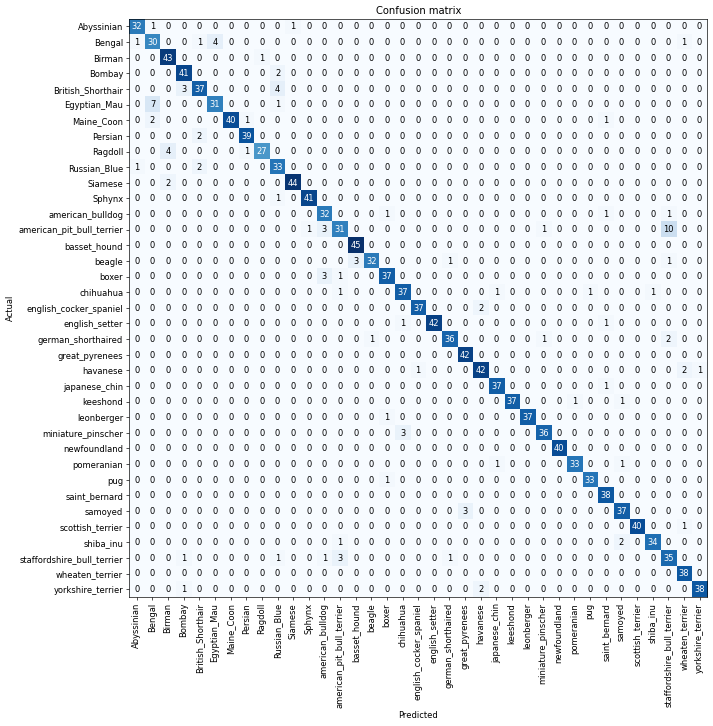

In [36]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(12,12),dpi=60)

To have a cleaner view of what is going on, we can choose to show the cells of confusion matrix with the most incorrect predictions.

In [37]:
interp.most_confused(min_val=5)

[('american_pit_bull_terrier', 'staffordshire_bull_terrier', 10),
 ('Egyptian_Mau', 'Bengal', 7)]

# Improving our model
In this part, we will study a range of techniques to improve the training of our model and make it better. It includes:
- Learning rate finder
- Transfer Learning process

## The learning rate finder

One of the most critical part in training a model os to find a good learning rate. If the predefined learning rate is too small, it will takes many epochs to train our model and it might result in time consuming and overfitting exposure. IF it is set too high, the detrimental effects of error rate increasing might be seen.

In [38]:
# Example of high learning rate
learn = cnn_learner(dls,resnet34,metrics=error_rate)
learn.fine_tune(1,base_lr=0.2)

epoch,train_loss,valid_loss,error_rate,time
0,9.363783,43.051037,0.903924,01:27


epoch,train_loss,valid_loss,error_rate,time
0,7.759617,29.350748,0.971583,01:25


In 2015, resercher Leslie Smith came up with a brilliant idea of learning rate finder [link](https://arxiv.org/abs/1506.01186). His idea starts with a very small learning rate and examine the loss over one mini-batch. Then, he increase learning rate by a certain percentage and keep doing that until the loss get worse. That the point we know that we have over-reacted and we should choose a learning rate lower than this point.

ValueError: not enough values to unpack (expected 2, got 1)

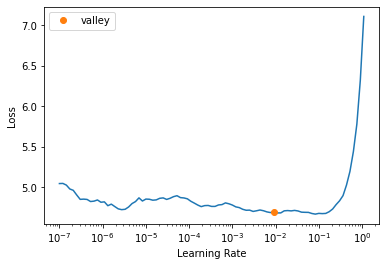

In [39]:
lr_min,lr_steep = learn.lr_find()

In [41]:
# rerun the training
learn = cnn_learner(dls,resnet34,metrics=error_rate)
learn.fine_tune(2,base_lr=0.008)

epoch,train_loss,valid_loss,error_rate,time
0,1.014067,0.404690,0.130582,01:29


epoch,train_loss,valid_loss,error_rate,time
0,0.865397,0.785443,0.220568,01:28
1,0.480247,0.299356,0.093369,01:24


## Unfreezing and transfer learning

Transfer learning will take a set of parameters that have been previously trained and throw away the last layer of pretrained model. Then we replace by a layer with random weights and we train that. 

The next task is to fine tune the newly added weight to align with our new objective. ```fine_tun``` is a method we called to operate that. It does 2 things:
- train the randomly added layers for one epoch with all other layer frozen
- unfreeze all of the layers and train them all for the number of epoch requested.

In [43]:
learn.fine_tune??

There are several parameters in fine_tune we shoud notice:
- self.freeze(): make only the last layer's weight get step and freeze the other layers.
- self.fit_one_cycle() : update the newly added weights in one cycle, it trains model without using fine_tune. In summary, it starts training at a lower learning rate, gradually increase ot for the first section of training and then gradually decrease it again for the last section of training. 


In [44]:
learn = cnn_learner(dls,resnet34,metrics=error_rate)
learn.fit_one_cycle(3,3e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.131244,0.339623,0.106225,01:30
1,0.533571,0.272031,0.083897,01:26
2,0.332284,0.235257,0.075101,01:26


SuggestedLRs(valley=6.918309736647643e-06)

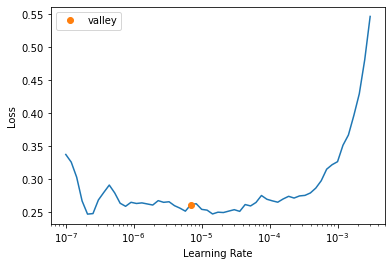

In [45]:
learn.unfreeze()
learn.lr_find()

In [46]:
# Lets train with a suitable learning rate
learn.fit_one_cycle(6,lr_max=1e-5)

epoch,train_loss,valid_loss,error_rate,time
0,0.247704,0.222702,0.071719,01:26
1,0.245497,0.211186,0.069689,01:26
2,0.211546,0.210558,0.067659,01:30
3,0.198770,0.204503,0.063599,01:29
4,0.190857,0.202116,0.066306,01:27
5,0.177307,0.202761,0.067659,01:23


Intuitively speaking, in transfer learning, the deepest layers (beginning layers) of our pretrained model might not need as high a learning rate  as the last ones, so we should probably use different learning rate approach for different layers. That what FastAI called <i> discriminative learning rate </i>. 

## Discriminative Learning rate

The idea behind this is simple: we apply lower learning rate for the early layers of the neural network and higher learning rate for the later ones. 

In FastAI, we will pass a Python ```slice``` object anywhere that a learning rate is expected. The first value of slice is the learning rate of the starting layer and the last value of the slice is the final layer. The layers in between share the multiplicatively equidistant learning rate throughout the slice.

In [47]:
# example
learn = cnn_learner(dls,resnet34,metrics=error_rate)
learn.fit_one_cycle(3,3e-3)
learn.unfreeze()
learn.fit_one_cycle(12,lr_max=slice(1e-6,1e-4))

epoch,train_loss,valid_loss,error_rate,time
0,1.105149,0.319647,0.104195,01:32
1,0.509816,0.279788,0.093369,01:28
2,0.319550,0.241098,0.087280,01:32


epoch,train_loss,valid_loss,error_rate,time
0,0.257214,0.241996,0.083221,01:32
1,0.256226,0.228803,0.078484,01:31
2,0.240209,0.225714,0.077131,01:33
3,0.202059,0.217118,0.071042,01:25
4,0.179049,0.209164,0.070365,01:25
5,0.177175,0.212497,0.065629,01:28
6,0.165256,0.202155,0.067659,01:31
7,0.150717,0.210655,0.070365,01:33
8,0.147985,0.206712,0.063599,01:34
9,0.132928,0.202588,0.066306,01:33


## Deeper Architecture

It literally increase the numbers of layers of our architecture (more activation functions, linear model). For instance, resnet architecture comes with 18,34,50,101,152 layer variants, pretrained with ImageNet. A larger version of the resnet returns a better training loss, but it can suffer more from overfitting.

In additions, the bigger model and larger batch-size is, the memory requirement for GPU is higher.

Another downside of training data with deeper architecture is time consuming, as it will take more time to train a larger model.µ

# Take home messages

So, in this part, we have learned some important practical tips:
- Preparing data for modelling (presizing)
- Fitting the model (learning rate finder, unfreezing, fine_tune, discriminative learning rate, epochs, deeper architecture)
- Entropy loss discusison